In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
df = pd.read_csv("emails.csv", encoding="latin-1")

df = df[['spam', 'text']]
df.columns = ['label', 'message']

df.head()

,label,message
0,1,Subject: naturally irresistible your corporate...
1,1,Subject: the stock trading gunslinger fanny i...
2,1,Subject: unbelievable new homes made easy im ...
3,1,Subject: 4 color printing special request add...
4,1,"Subject: do not have money , get software cds ..."


In [5]:
cv = CountVectorizer(max_features=100)

X = cv.fit_transform(df["message"])

y = df["label"]

print("Dataset Loaded Successfully")
print("Total Emails:", len(df))

Dataset Loaded Successfully
Total Emails: 5728


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4582, 100)
Testing Data Shape: (1146, 100)


In [7]:
model = MultinomialNB()
model.fit(X_train, y_train)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print("Models Trained Successfully")

Models Trained Successfully


In [8]:
import shap

X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

explainer = shap.Explainer(
    model.predict_proba,
    X_train_dense[:20]
)

print("SHAP Ready")

SHAP Ready


PermutationExplainer explainer: 21it [00:13,  1.51it/s]                        


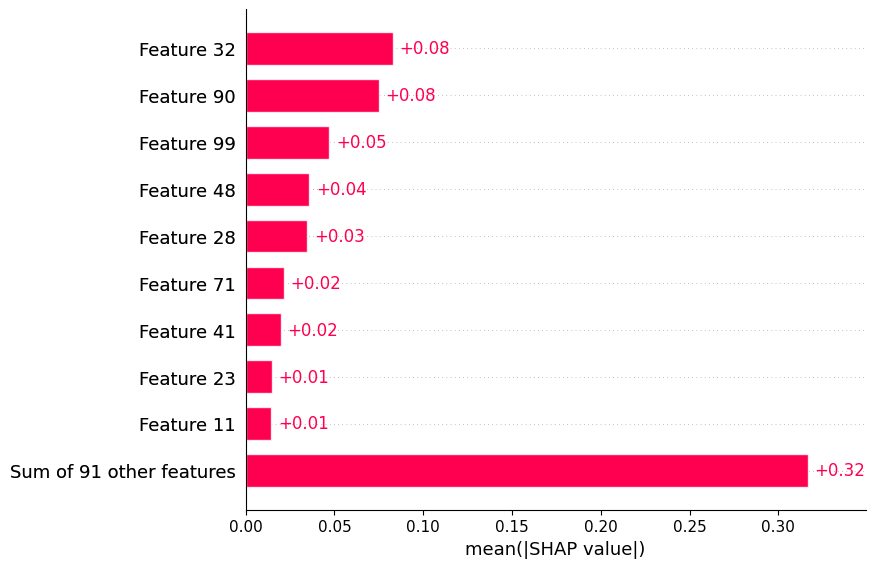

In [9]:
shap_values = explainer(X_test_dense[:20])

shap.plots.bar(shap_values[:, :, 1])

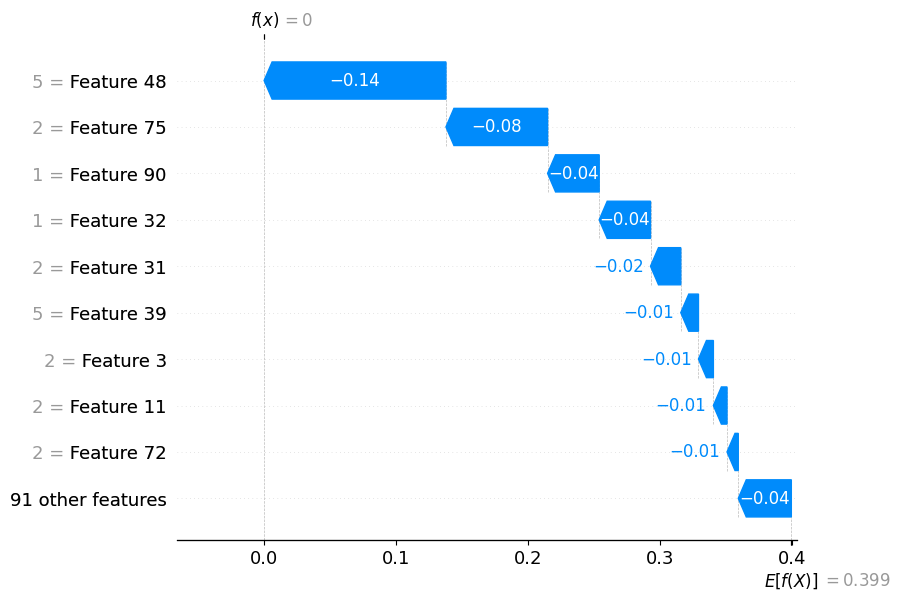

In [10]:
shap.plots.waterfall(shap_values[0, :, 1])

# Bias Analysis

The spam email dataset does not contain sensitive attributes such as gender, age, race, or religion.

Therefore, direct fairness analysis across protected groups could not be performed.

Future versions of the dataset may include demographic attributes to enable fairness evaluation.

# Mitigation Recommendations

1. Retrain the model regularly with updated email data.

2. Monitor false positive and false negative predictions.

3. Remove noisy or misleading features.

4. Perform fairness analysis if demographic attributes become available.

5. Use explainability tools such as SHAP to improve transparency and trust.

# Conclusion

A spam email classification model was analyzed using SHAP.

Feature importance and local explanations were generated to understand model behavior.

Bias analysis was performed based on available dataset attributes, and mitigation recommendations were proposed to improve model reliability and transparency.